In [21]:
import functools
import operator

from typing import Annotated, Literal, Sequence, TypedDict
from typing_extensions import TypedDict

from IPython.display import Image, display
from langgraph.graph import END, StateGraph
from langgraph.prebuilt import ToolNode
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI

# import google.generativeai as genai
# from langchain_google_genai import GoogleGenerativeAI
# from langchain_google_genai import ChatGoogleGenerativeAI

lang_model_name = "gpt-4o-mini"
# embedding_model_name = "gemma-2-embed"
# lang_model_name = "tiger-gemma2"

max_tokens = 1024

## LLM Initialization

In [22]:
# llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro-latest", google_api_key=".........",convert_system_message_to_human=True)
# ChatOpenAI.model_rebuild()
llm = ChatOpenAI(model=lang_model_name, temperature=0)
# llm = ChatOllama(
#     model=lang_model_name,
#     temperature=0.8,
#     num_predict=max_tokens,
#     num_gpu=-1
# )

## Agent Runnable and Tools

In [23]:
#Create agent definition
def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Always Use the provided tools to progress towards answering the question."
                " You have access to the following tools: {tool_names}.\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_tools(tools)

#to store email threads
thread_data = []

import random

@tool
def choose_number()->int:
    """Select a random number between 1 and 100."""
    return random.randint(1, 100)
    

@tool
def double_the_number(
    number_to_double: Annotated[int,"The number to be doubled"]
    )->int:
    """Double the given number."""
    return number_to_double * 2


@tool
def add_number(
    number_to_add: Annotated[int,"The number to be added"]
    )->int:
    """Double the given number."""
    return number_to_add + 10


@tool
def divide_number(
    number_to_divide: Annotated[int,"The number to be divided"]
    )->int:
    """Double the given number."""
    return number_to_divide / 2

@tool
def subtract_original_number(
    number_to_subtract: Annotated[int,"The number to be subtracted"],
    original_number: Annotated[int,"Original number"],

    )->int:
    """Subtract the given number from original number."""
    return number_to_subtract - original_number


## State Definition

In [24]:
# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str


## Agent/Tool Nodes

In [25]:


# Helper function to create a node for a given agent
import time
def agent_node(state, agent, name):
    result = agent.invoke(state)
    
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, ToolMessage):
        pass
    else:
        result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }

   
# Person1 agent and node
person1_agent = create_agent(
    llm,
    [choose_number],
    system_message=""" 
        Choose a whole number between 1 and 100.
    """,
)
person1_node = functools.partial(agent_node, agent=person1_agent, name="Person1")


# Person2 agent and node
person2_agent = create_agent(
    llm,
    [double_the_number],
    system_message=""" 
        Double the number
    """,
)
person2_node = functools.partial(agent_node, agent=person2_agent, name="Person2")


# Person3 agent and node
person3_agent = create_agent(
    llm,
    [add_number],
    system_message=""" 
        Add 10 to the number
    """,
)
person3_node = functools.partial(agent_node, agent=person3_agent, name="Person3")

# Person4 agent and node
person4_agent = create_agent(
    llm,
    [divide_number],
    system_message=""" 
        Divide number by 2
    """,
)
person4_node = functools.partial(agent_node, agent=person4_agent, name="Person4")


# Person5 agent and node
person5_agent = create_agent(
    llm,
    [subtract_original_number],
    system_message=""" 
        Subtract your original number to the number
    """,
)
person5_node = functools.partial(agent_node, agent=person5_agent, name="Person5")

tools = [choose_number,double_the_number,add_number,divide_number, subtract_original_number]
tool_node = ToolNode(tools)

final_answer_agent = create_agent(
    llm,
    [],
    system_message="""
        Answer the final answer with the following prefix: FINAL ANSWER
        and do closing comments for math magic trick.
    """
)
final_answer_node = functools.partial(agent_node, agent=final_answer_agent, name="FinalAnswerer")

## Routers

In [26]:
def router(state) -> Literal["call_tool", "__end__", "continue"]:
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "__end__"
    if len(last_message.content) == 0:
        # Remove the last empty message
        # Sometimes llm returns a blank response and so remove the message and retry the node
        state["messages"].pop()
        return "_repeat_"
    return "continue"



## Build State Graph

In [27]:

workflow = StateGraph(AgentState)

workflow.add_node("Person1", person1_node)
workflow.add_node("Person2", person2_node)
workflow.add_node("Person3", person3_node)
workflow.add_node("Person4", person4_node)
workflow.add_node("Person5", person5_node)
workflow.add_node("FinalAnswerer", final_answer_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Person1",
    router,
    {"continue": "Person2", "call_tool": "call_tool","_repeat_": "Person1", "__end__": "Person2"},
)
workflow.add_conditional_edges(
    "Person2",
    router,
    {"continue": "Person3", "call_tool": "call_tool","_repeat_": "Person2", "__end__": "Person3"},
)
workflow.add_conditional_edges(
    "Person3",
    router,
    {"continue": "Person4", "call_tool": "call_tool","_repeat_": "Person3", "__end__": "Person4"},
)
workflow.add_conditional_edges(
    "Person4",
    router,
    {"continue": "Person5", "call_tool": "call_tool","_repeat_": "Person4", "__end__": "Person5"},
)
workflow.add_conditional_edges(
    "Person5",
    router,
    {"continue": "FinalAnswerer", "call_tool": "call_tool","_repeat_": "Person5", "__end__": "FinalAnswerer"},
)
workflow.add_conditional_edges(
    "FinalAnswerer",
    router,
    {"continue": END, "_repeat_": "FinalAnswerer", "__end__": END},
)

workflow.add_conditional_edges(
    "call_tool",
    # Each agent node updates the 'sender' field
    # the tool calling node does not, meaning
    # this edge will route back to the original agent
    # who invoked the tool
    lambda x: x["sender"],
    {
        "Person1": "Person1",
        "Person2": "Person2",
        "Person3": "Person3",
        "Person4": "Person4",
        "Person5": "Person5",
    },
)
workflow.set_entry_point("Person1")
graph = workflow.compile()


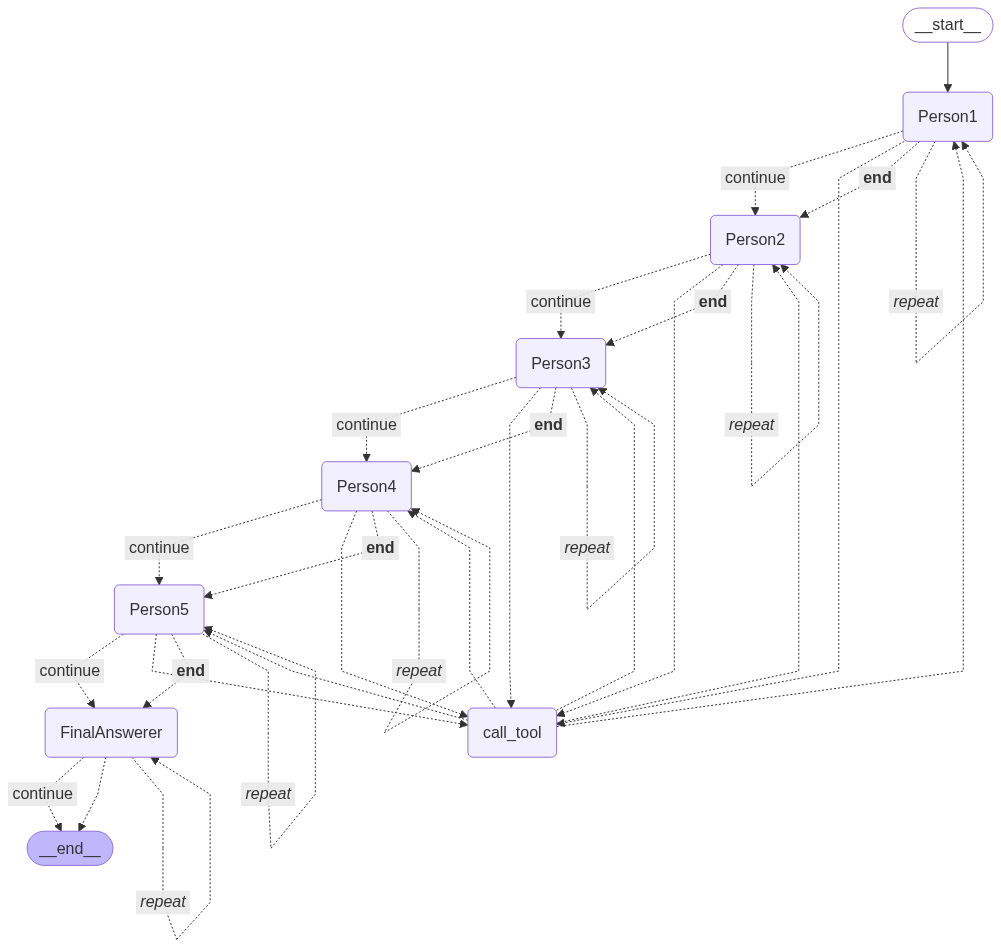

In [28]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [29]:

# inputs = {
#     "messages": [
#         HumanMessage(content="Let's play a game of guessing a number")
#     ],
#     'sender': 'Person1'
# }
# graph.invoke(inputs)


In [30]:
events = graph.stream(
    {
        "messages": [
            HumanMessage(
                content="We are going to play a math magic trick. Choose a number? This is your original number."
            )
        ],
        'sender': 'Person1'
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 20},
)

try:
    for event in events:  
        print(event)       # Use the variable directly
        print("----")
except Exception as e:     # Use 'e' for convention, and be more specific if possible
    print(f"Error processing event: {e}")

#### write.value {'messages': [HumanMessage(content='We are going to play a math magic trick. Choose a number? This is your original number.', additional_kwargs={}, response_metadata={})], 'sender': 'Person1'}


/tmp/ipykernel_240640/3339081165.py:10: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


#### write.value Person1
#### ends: {'continue': 'Person2', 'call_tool': 'call_tool', '_repeat_': 'Person1', '__end__': 'Person2'}
#### result: ['call_tool']
#### write.value Person1
{'Person1': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_1lsCgkvsVGvu9TlJOS4XyI9Y', 'function': {'arguments': '{}', 'name': 'choose_number'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 111, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-Bkp1hj1lUY7CVOvopQWksd6saEMwX', 'finish_reason': 'tool_calls', 'logprobs': None}, name='Person1', id='run--48c0c6b0-8229-4145-961b-3c9d21dea1c2-0', tool_calls=[{'name': 'choose_number', 'args':

/tmp/ipykernel_240640/3339081165.py:10: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


#### write.value Person1
#### ends: {'continue': 'Person2', 'call_tool': 'call_tool', '_repeat_': 'Person1', '__end__': 'Person2'}
#### result: ['continue']
#### write.value Person1
{'Person1': {'messages': [AIMessage(content="I have chosen the number 25 as my original number. What's the next step in the math magic trick?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 133, 'total_tokens': 156, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-Bkp1i4lWwxBtEVYadcnuq1EX5U9f7', 'finish_reason': 'stop', 'logprobs': None}, name='Person1', id='run--1c0ff9d3-dff6-47f7-876c-4b93dd3dc3be-0', usage_metadata={'input_tokens': 133, 'output_tokens': 23, 'total_tokens': 156, 'input_token

...

/tmp/ipykernel_240640/3339081165.py:10: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


#### write.value Person4
#### ends: {'continue': 'Person5', 'call_tool': 'call_tool', '_repeat_': 'Person4', '__end__': 'Person5'}
#### result: ['continue']
#### write.value Person4
{'Person4': {'messages': [AIMessage(content="After adding 10 to the doubled number (50), we get 60. Now, let's divide that by 2. The result is 25. \n\nWhat’s the next step in the trick?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 291, 'total_tokens': 333, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-Bkp1mV0FoMNfspnn2cG7ShpSYex4K', 'finish_reason': 'stop', 'logprobs': None}, name='Person4', id='run--ec66e865-eb31-46ed-9f80-11f8edb35bca-0', usage_metadata={'input_tokens': 291, 'output_to

/tmp/ipykernel_240640/3339081165.py:10: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)


#### write.value Person5
#### ends: {'continue': 'FinalAnswerer', 'call_tool': 'call_tool', '_repeat_': 'Person5', '__end__': 'FinalAnswerer'}
#### result: ['continue']
#### write.value Person5
{'Person5': {'messages': [AIMessage(content="Now, subtract your original number (25) from the result (25). Let's do that calculation!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 357, 'total_tokens': 378, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-Bkp1nvh2iRQJwFxt7LUu16dQddLjl', 'finish_reason': 'stop', 'logprobs': None}, name='Person5', id='run--3894740e-c1d8-4f46-bd49-e998e19daa30-0', usage_metadata={'input_tokens': 357, 'output_tokens': 21, 'total_tokens': 378, 'input_t

/tmp/ipykernel_240640/3339081165.py:10: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  result = AIMessage(**result.dict(exclude={"type", "name"}), name=name)
